# EDA

## Import Libraries & Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('accidents_2017_to_2023_english.csv')

1.	How well do standard multiclass classification models predict traffic accident severity?

2.	How does handling class imbalance affect the performance of these models, and how do the main methods of class imbalance handling compare?

3.	Which features are most important in predicting traffic accident severity?

## First Data Inspection

In [ ]:
df.shape         

(463152, 27)

In [4]:
df.dtypes

inverse_data           object
week_day               object
hour                   object
state                  object
road_id               float64
km                     object
city                   object
cause_of_accident      object
type_of_accident       object
victims_condition      object
weather_timestamp      object
road_direction         object
wheather_condition     object
road_type              object
road_delineation       object
people                  int64
deaths                  int64
slightly_injured        int64
severely_injured        int64
uninjured               int64
ignored                 int64
total_injured           int64
vehicles_involved       int64
latitude              float64
longitude             float64
regional               object
police_station         object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463152 entries, 0 to 463151
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   inverse_data        463152 non-null  object 
 1   week_day            463152 non-null  object 
 2   hour                463152 non-null  object 
 3   state               463152 non-null  object 
 4   road_id             462162 non-null  float64
 5   km                  462162 non-null  object 
 6   city                463152 non-null  object 
 7   cause_of_accident   463152 non-null  object 
 8   type_of_accident    463152 non-null  object 
 9   victims_condition   463152 non-null  object 
 10  weather_timestamp   463152 non-null  object 
 11  road_direction      463152 non-null  object 
 12  wheather_condition  463152 non-null  object 
 13  road_type           463152 non-null  object 
 14  road_delineation    463152 non-null  object 
 15  people              463152 non-nul

In [6]:
pd.set_option('display.max_columns', None)

df.head()

,inverse_data,week_day,hour,state,road_id,km,city,cause_of_accident,type_of_accident,victims_condition,weather_timestamp,road_direction,wheather_condition,road_type,road_delineation,people,deaths,slightly_injured,severely_injured,uninjured,ignored,total_injured,vehicles_involved,latitude,longitude,regional,police_station
0,2017-01-01,sunday,01:45:00,RS,116.0,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.50712,-50.94118,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.0,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.75400,-49.12660,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.0,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.96180,-38.09530,SPRF-BA,DEL01-BA
3,2017-01-01,sunday,06:30:00,PA,316.0,"72,5",CASTANHAL,Driver's lack of attention to conveyance,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,4,1,0,0,3,0,0,3,-1.28998,-47.83483,SPRF-PA,DEL01-PA
4,2017-01-01,sunday,09:00:00,GO,20.0,"220,5",POSSE,Road's defect,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,3,0,2,1,0,0,3,1,-14.14221,-46.32259,SPRF-DF,DEL02-DF


## Column Renaming

In [7]:
# Rename columns
df.rename(columns={
    'inverse_data': 'Date',
    'week_day': 'Day',
    'hour': 'Hour',
    'state': 'State',
    'road_id': 'Road_ID',
    'km': 'Road_Km',
    'city': 'City',
    'cause_of_accident': 'Accident_Cause',
    'type_of_accident': 'Accident_Type',
    'victims_condition': 'Victims_Condition',
    'weather_timestamp': 'Day_Phase',
    'road_direction': 'Km_Direction',
    'wheather_condition': 'Weather_Condition',
    'road_type': 'Road_Type',
    'road_delineation': 'Road_Delineation',
    'people': 'People',
    'deaths': 'Deaths',
    'slightly_injured': 'Slightly_Injured',
    'severely_injured': 'Severely_Injured',
    'uninjured': 'Uninjured',
    'ignored': 'Ignored',
    'total_injured': 'Total_Injured',
    'vehicles_involved': 'Vehicles_Involved',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'regional': 'Regional',
    'police_station': 'Police_Station'
}, inplace=True)

# Verify the changes
df.head()

,Date,Day,Hour,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station
0,2017-01-01,sunday,01:45:00,RS,116.0,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.50712,-50.94118,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.0,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.75400,-49.12660,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.0,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.96180,-38.09530,SPRF-BA,DEL01-BA
3,2017-01-01,sunday,06:30:00,PA,316.0,"72,5",CASTANHAL,Driver's lack of attention to conveyance,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,4,1,0,0,3,0,0,3,-1.28998,-47.83483,SPRF-PA,DEL01-PA
4,2017-01-01,sunday,09:00:00,GO,20.0,"220,5",POSSE,Road's defect,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,3,0,2,1,0,0,3,1,-14.14221,-46.32259,SPRF-DF,DEL02-DF


In [ ]:
df.dtypes         

Date                  object
Day                   object
Hour                  object
State                 object
Road_ID              float64
Road_Km               object
City                  object
Accident_Cause        object
Accident_Type         object
Victims_Condition     object
Day_Phase             object
Km_Direction          object
Weather_Condition     object
Road_Type             object
Road_Delineation      object
People                 int64
Deaths                 int64
Slightly_Injured       int64
Severely_Injured       int64
Uninjured              int64
Ignored                int64
Total_Injured          int64
Vehicles_Involved      int64
Latitude             float64
Longitude            float64
Regional              object
Police_Station        object
dtype: object

## Data Type Converting & Merging

In [9]:
# Combine Date and Hour into a single datetime column
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Hour'].astype(str))

# Drop the original Date and Hour columns
df.drop(['Date', 'Hour'], axis=1, inplace=True)

In [10]:
# The changes
print(df.columns.tolist())
print(f"\nDatetime dtype: {df['Datetime'].dtype}")
print(f"\nFirst few rows:\n{df[['Datetime']].head()}")

['Day', 'State', 'Road_ID', 'Road_Km', 'City', 'Accident_Cause', 'Accident_Type', 'Victims_Condition', 'Day_Phase', 'Km_Direction', 'Weather_Condition', 'Road_Type', 'Road_Delineation', 'People', 'Deaths', 'Slightly_Injured', 'Severely_Injured', 'Uninjured', 'Ignored', 'Total_Injured', 'Vehicles_Involved', 'Latitude', 'Longitude', 'Regional', 'Police_Station', 'Datetime']

Datetime dtype: datetime64[ns]

First few rows:
             Datetime
0 2017-01-01 01:45:00
1 2017-01-01 01:00:00
2 2017-01-01 04:40:00
3 2017-01-01 06:30:00
4 2017-01-01 09:00:00


In [11]:
# Move Datetime to the front
cols = ['Datetime'] + [col for col in df.columns if col != 'Datetime']
df = df[cols]

print(df.columns.tolist())

['Datetime', 'Day', 'State', 'Road_ID', 'Road_Km', 'City', 'Accident_Cause', 'Accident_Type', 'Victims_Condition', 'Day_Phase', 'Km_Direction', 'Weather_Condition', 'Road_Type', 'Road_Delineation', 'People', 'Deaths', 'Slightly_Injured', 'Severely_Injured', 'Uninjured', 'Ignored', 'Total_Injured', 'Vehicles_Involved', 'Latitude', 'Longitude', 'Regional', 'Police_Station']


In [12]:
# Convert Road_Km (handling European decimal format)
df['Road_Km'] = pd.to_numeric(df['Road_Km'].str.replace(',', '.'), errors='coerce')

In [13]:
df.info()         

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463152 entries, 0 to 463151
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Datetime           463152 non-null  datetime64[ns]
 1   Day                463152 non-null  object        
 2   State              463152 non-null  object        
 3   Road_ID            462162 non-null  float64       
 4   Road_Km            462162 non-null  float64       
 5   City               463152 non-null  object        
 6   Accident_Cause     463152 non-null  object        
 7   Accident_Type      463152 non-null  object        
 8   Victims_Condition  463152 non-null  object        
 9   Day_Phase          463152 non-null  object        
 10  Km_Direction       463152 non-null  object        
 11  Weather_Condition  463152 non-null  object        
 12  Road_Type          463152 non-null  object        
 13  Road_Delineation   463152 non-null  object  

## Null Values Handling

In [14]:
df.isnull().sum()              # Missing values per column

Datetime                0
Day                     0
State                   0
Road_ID               990
Road_Km               990
City                    0
Accident_Cause          0
Accident_Type           0
Victims_Condition       0
Day_Phase               0
Km_Direction            0
Weather_Condition       0
Road_Type               0
Road_Delineation        0
People                  0
Deaths                  0
Slightly_Injured        0
Severely_Injured        0
Uninjured               0
Ignored                 0
Total_Injured           0
Vehicles_Involved       0
Latitude                0
Longitude               0
Regional               10
Police_Station       1310
dtype: int64

In [15]:
df[df['Regional'].isna()]

,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station
198347,2019-06-19 17:45:00,wednesday,RJ,NaN,NaN,RIO DE JANEIRO,Disrespect of safe distance from the next car,Rear-end collision,With injured victims,Sunset,Not informed,Clear sky,Multiple,Not Reported,4,0,2,0,1,1,2,3,-22.877100,-43.27625,NaN,NaN
200708,2019-07-09 13:00:00,tuesday,RJ,NaN,NaN,RIO DE JANEIRO,Driver broke the laws of transit,Side impact collision,Without victims,Day,Not informed,Sunny,Simple,Straight,4,0,0,0,3,1,0,2,-22.905230,-43.19214,NaN,NaN
243476,2020-12-23 20:30:00,wednesday,BA,116.0,710.0,MANOEL VITORINO,Alcohol consumption,Side impact collision,Without victims,Night,Decreasing,Ignored,Simple,Straight,3,0,0,0,3,0,0,2,-14.115820,-40.22868,NaN,NaN
376758,2022-02-15 14:30:00,tuesday,PE,NaN,NaN,RECIFE,Driver's lack of reaction,Collision with object,Without victims,Day,Not informed,Sunny,Simple,Straight,1,0,0,0,1,0,0,1,-8.084755,-34.88645,NaN,NaN
394400,2022-04-01 12:20:00,friday,DF,NaN,NaN,BRASILIA,Driver failed to keep distance from the vehicl...,Rear-end collision,Without victims,Day,Not informed,Clear sky,Double,Straight,3,0,0,0,2,1,0,2,-15.817520,-47.94996,NaN,NaN
399374,2022-08-11 07:40:00,thursday,DF,NaN,NaN,BRASILIA,Lane change maneuver,Rear-end collision,With injured victims,Day,Not informed,Clear sky,Simple,Not Reported,2,0,1,0,1,0,1,2,-15.792340,-47.88382,NaN,NaN
419669,2023-01-16 10:00:00,monday,DF,NaN,NaN,BRASILIA,Lane change maneuver,Side collision (same direction),Without victims,Day,Not informed,Clear sky,Double,Straight,4,0,0,0,4,0,0,3,-15.815890,-47.94959,NaN,NaN
423473,2023-04-12 08:05:00,wednesday,DF,NaN,NaN,BRASILIA,Driver's lack of reaction,Rear-end collision,Without victims,Day,Not informed,Clear sky,Double,Intersection,2,0,0,0,2,0,0,2,-15.739530,-47.89059,NaN,NaN
435999,2023-02-10 16:10:00,friday,DF,NaN,NaN,BRASILIA,Lane change maneuver,Broadside collision,Without victims,Day,Not informed,Clear sky,Double,Straight,2,0,0,0,2,0,0,2,-15.800410,-47.96791,NaN,NaN
460744,2023-08-14 09:30:00,monday,DF,NaN,NaN,BRASILIA,Stopping at a prohibited place,Rear-end collision,Without victims,Day,Not informed,Clear sky,Simple,Straight,7,0,0,0,6,1,0,4,-15.833000,-47.92371,NaN,NaN


In [16]:
df = df.dropna(subset=['Regional'])

In [17]:
df[df['Police_Station'].isna()]

,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station
65369,2017-08-16 05:20:00,wednesday,RJ,NaN,NaN,ITAGUAI,Animals on the road,Animal collision,Without victims,Night,Not informed,Drizzle,Double,Straight,4,0,0,0,1,3,0,1,-22.850040,-43.81155,SPRF-RJ,NaN
97390,2018-05-31 02:00:00,thursday,MG,267.0,112.6,JUIZ DE FORA,Alcohol consumption,Pedestrian collision,With injured victims,Night,Increasing,Clear sky,Simple,Straight,2,0,0,1,1,0,1,1,-21.709590,-43.41657,SPRF-MG,NaN
97514,2018-06-02 15:35:00,saturday,MG,262.0,567.3,CORREGO DANTA,Driver broke the laws of transit,Broadside collision,With injured victims,Day,Increasing,Clear sky,Simple,Roundabout,3,0,1,0,2,0,1,2,-19.737260,-46.01374,SPRF-MG,NaN
98456,2018-06-21 05:00:00,thursday,MG,262.0,574.0,CORREGO DANTA,Driver's lack of attention to conveyance,Overturn,With injured victims,Sunrise,Decreasing,Clear sky,Simple,Curve,3,0,1,0,2,0,1,1,-19.729610,-46.01854,SPRF-MG,NaN
99448,2018-07-12 20:30:00,thursday,MG,459.0,85.6,CONGONHAL,Driver's lack of attention to conveyance,Broadside collision,With injured victims,Night,Decreasing,Cloudy,Simple,Straight,3,0,1,0,2,0,1,2,-22.149950,-46.02631,SPRF-MG,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462833,2023-08-30 11:25:00,wednesday,AC,364.0,139.0,RIO BRANCO,Driver's lack of reaction,Pedestrian collision,With injured victims,Day,Decreasing,Clear sky,Double,Straight,3,0,1,1,1,0,2,3,-9.953593,-67.86120,SPRF-AC,NaN
462892,2023-08-30 21:30:00,wednesday,AC,364.0,128.0,RIO BRANCO,Driver's lack of reaction,Run-off-road,Without victims,Night,Increasing,Clear sky,Simple,Straight,1,0,0,0,0,1,0,1,-10.026440,-67.82069,SPRF-AC,NaN
462920,2023-08-31 07:43:00,thursday,AP,210.0,1.0,MACAPA,Driver's lack of reaction,Rear-end collision,With injured victims,Day,Increasing,Clear sky,Double,Straight,3,0,1,2,0,0,3,2,0.078167,-51.06999,SPRF-AP,NaN
462984,2023-08-31 18:20:00,thursday,RR,174.0,511.0,BOA VISTA,Excessive use of the car's tire,Run-off-road,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,2,0,1,0,1,0,1,1,2.861408,-60.69804,SPRF-RR,NaN


In [18]:
df['Police_Station'] = df['Police_Station'].fillna('UNKNOWN')

In [19]:
# Create flag column + fill missing
df['Missing_Road_Data'] = df['Road_ID'].isna()
df['Road_ID'] = df['Road_ID'].fillna('NO_ROAD')
df['Road_Km'] = df['Road_Km'].fillna(-1)

In [20]:
print(df.isnull().sum().sum())

0


## Duplicate Values Handling

In [21]:
df.duplicated().sum()

np.int64(9)

In [22]:
duplicates = df[df.duplicated(keep=False)]
display(duplicates)

,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station,Missing_Road_Data
19243,2017-10-20 14:25:00,friday,SC,282.0,483.9,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.856710,-52.24642,SPRF-SC,DEL07-SC,False
75470,2017-10-20 14:25:00,friday,SC,282.0,483.9,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.856710,-52.24642,SPRF-SC,DEL07-SC,False
79108,2017-11-11 17:00:00,saturday,GO,60.0,201.8,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886220,-49.62302,SPRF-GO,DEL01-GO,False
79109,2017-11-11 17:00:00,saturday,GO,60.0,201.8,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886220,-49.62302,SPRF-GO,DEL01-GO,False
80504,2017-11-19 15:40:00,sunday,RJ,40.0,113.0,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719200,-43.28960,SPRF-RJ,DEL01-RJ,False
80505,2017-11-19 15:40:00,sunday,RJ,40.0,113.0,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719200,-43.28960,SPRF-RJ,DEL01-RJ,False
353536,2021-12-16 17:30:00,thursday,SC,101.0,135.3,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005010,-48.62677,SPRF-SC,DEL04-SC,False
354092,2021-12-16 17:30:00,thursday,SC,101.0,135.3,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005010,-48.62677,SPRF-SC,DEL04-SC,False
381910,2022-03-30 20:19:00,wednesday,GO,50.0,263.5,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052100,-47.86300,SPRF-GO,DEL06-GO,False
381911,2022-03-30 20:19:00,wednesday,GO,50.0,263.5,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052100,-47.86300,SPRF-GO,DEL06-GO,False


Leaving duplicates there for two reasons:

1. Out of a total of 463,151 rows, 9 duplicates were found. According to the duplicate data, these records should not affect future results.

2. This could be actual data generated at the same time, but I am not 100% sure

In [23]:
df.describe()                  # Stats for numeric columns

,Datetime,Road_Km,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude
count,463142,463142.000000,463142.000000,463142.000000,463142.00000,463142.000000,463142.000000,463142.000000,463142.000000,463142.000000,4.631420e+05,4.631420e+05
mean,2020-03-02 14:11:04.604592128,260.836578,2.362355,0.079237,0.83548,0.259536,1.044038,0.144064,1.095016,1.645711,-2.343337e+03,-8.925169e+03
min,2017-01-01 00:00:00,-1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,-1.033383e+09,-4.016764e+09
25%,2018-05-05 19:45:00,77.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,-2.533152e+01,-5.030311e+01
50%,2020-01-29 14:42:30,195.000000,2.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,2.000000,-2.042041e+01,-4.780831e+01
75%,2021-11-22 19:26:15,410.000000,3.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,2.000000,-1.282657e+01,-4.264240e+01
max,2023-08-31 23:59:00,1454.500000,80.000000,21.000000,61.00000,31.000000,73.000000,54.000000,66.000000,23.000000,1.630000e+02,7.170000e+02
std,NaN,227.536850,1.924804,0.332172,1.07528,0.602819,1.502404,0.438165,1.205355,0.731386,1.519129e+06,5.903107e+06


## Graphs

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463142 entries, 0 to 463151
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Datetime           463142 non-null  datetime64[ns]
 1   Day                463142 non-null  object        
 2   State              463142 non-null  object        
 3   Road_ID            463142 non-null  object        
 4   Road_Km            463142 non-null  float64       
 5   City               463142 non-null  object        
 6   Accident_Cause     463142 non-null  object        
 7   Accident_Type      463142 non-null  object        
 8   Victims_Condition  463142 non-null  object        
 9   Day_Phase          463142 non-null  object        
 10  Km_Direction       463142 non-null  object        
 11  Weather_Condition  463142 non-null  object        
 12  Road_Type          463142 non-null  object        
 13  Road_Delineation   463142 non-null  object       

In [25]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Univariate

__Deaths distribution__

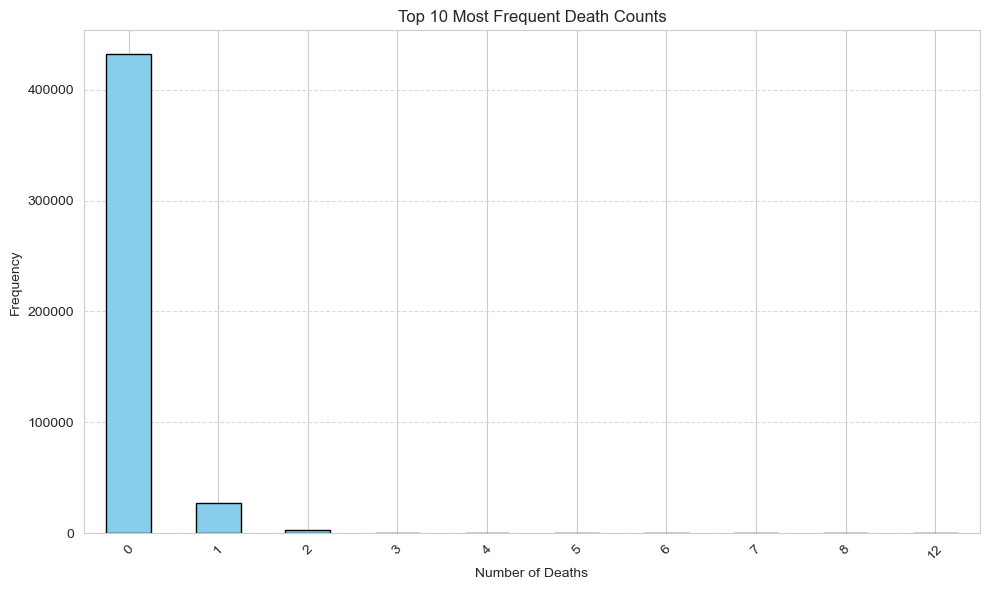

In [26]:
# Plot
plt.figure(figsize=(10, 6))
df['Deaths'].value_counts().head(10).plot(kind='bar', color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel('Number of Deaths')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Death Counts')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

__Ignored distribution__

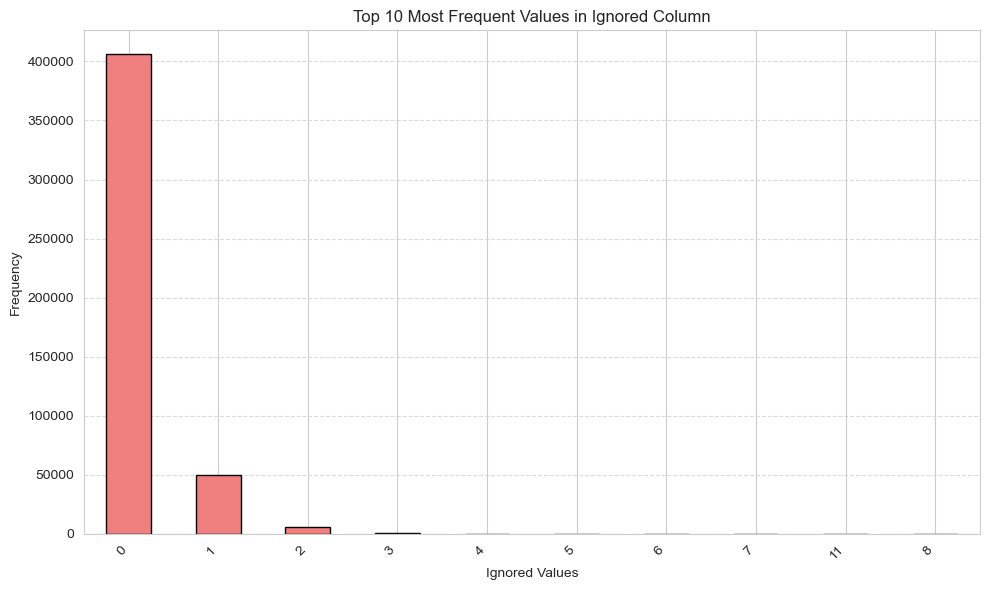

np.float64(0.12359060504121847)

In [27]:

# Create bar plot
plt.figure(figsize=(10, 6))
df['Ignored'].value_counts().head(10).plot(kind='bar', color='lightcoral', edgecolor='black')

# Labels and title
plt.xlabel('Ignored Values')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Values in Ignored Column')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
# How often is it non-zero?
display((df['Ignored'] > 0).mean())

12% people were ignored during the accident

__Check possible mistake__

In [28]:
mismatch = df['Total_Injured'] != (
  df['Slightly_Injured'] +
  df['Severely_Injured'])
print(mismatch.sum(), "mismatches")

0 mismatches


Confirming there are no mistakes with Total_Injured

In [29]:
df[['Vehicles_Involved',
   'People']].describe()

,Vehicles_Involved,People
count,463142.000000,463142.000000
mean,1.645711,2.362355
std,0.731386,1.924804
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,2.000000,3.000000
max,23.000000,80.000000


In [30]:
# People should be >= vehicles
(df['People'] < df[
  'Vehicles_Involved']).sum()

np.int64(0)

Logical test to verify data

__Accident_Cause Distribution__

In [31]:
df['Accident_Cause'].nunique()

85

In [32]:
df['Accident_Cause'].value_counts().head(20)

Accident_Cause
Driver's lack of attention to conveyance                           107788
Incompatible velocity                                               43722
Driver's lack of reaction                                           40886
Driver broke the laws of transit                                    29318
Alcohol consumption                                                 22140
Disrespect of safe distance from the next car                       17930
Driver was sleeping                                                 16820
Mechanical loss/defect of vehicle                                   15850
Acessing the road without seeing the presence of other vehicles     14974
Slippery track                                                      12649
Driver failed to keep distance from the vehicle in front            12262
Alcohol ingestion by the driver                                     11229
Animals on the road                                                 10533
The driver passed the n

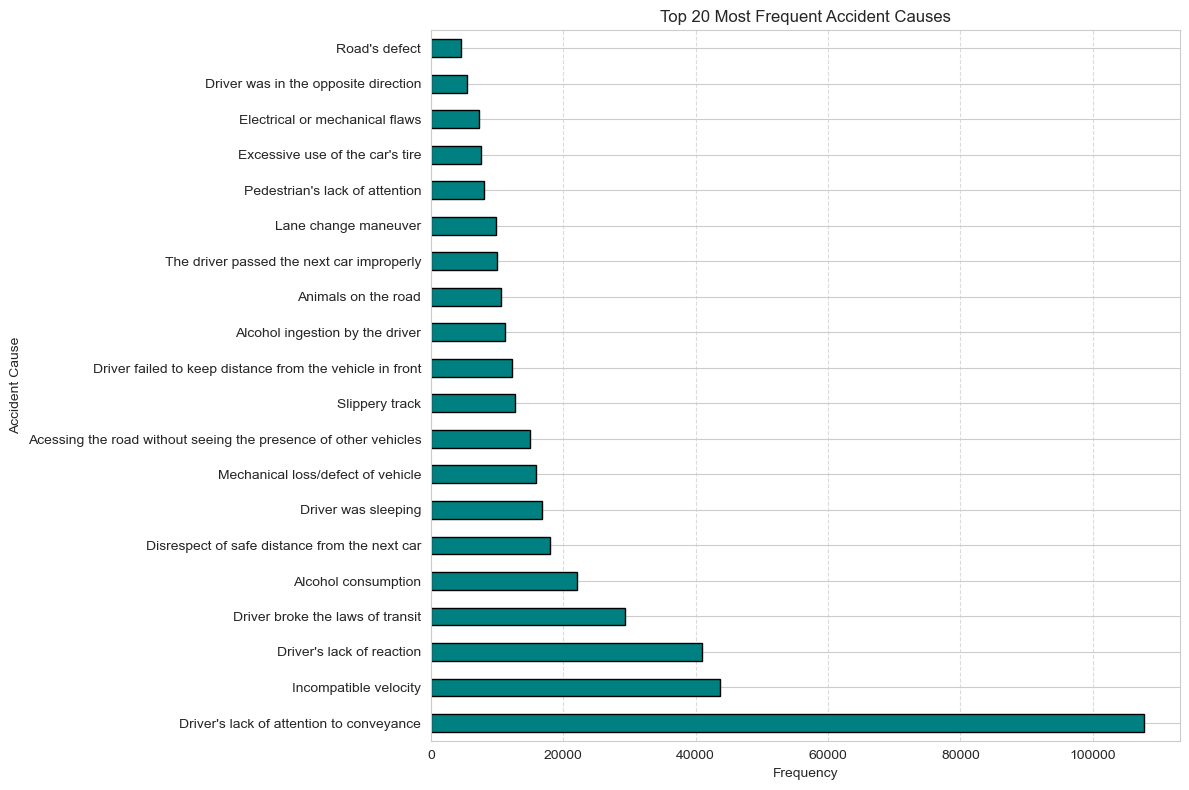

In [33]:
# Horizontal bar chart
plt.figure(figsize=(12, 8))
df['Accident_Cause'].value_counts().head(20).plot(kind='barh', color='teal', edgecolor='black')

# Labels and title
plt.xlabel('Frequency')
plt.ylabel('Accident Cause')
plt.title('Top 20 Most Frequent Accident Causes')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [34]:

# How many % does the top 10 cover?
top10 = df['Accident_Cause'].value_counts(
  normalize=True).head(10).sum()
print(f"Top 10 cover {top10:.1%}")

Top 10 cover 69.5%


__Contextual categoricals__

In [35]:
for col in ['Day_Phase','Weather_Condition','Road_Type','Road_Delineation','Km_Direction']:
    display(col, df[col].value_counts().to_dict())

'Day_Phase'

{'Day': 253131, 'Night': 161661, 'Sunset': 25549, 'Sunrise': 22801}

'Weather_Condition'

{'Clear sky': 269954,
 'Cloudy': 78677,
 'Rainy': 54136,
 'Sunny': 32767,
 'Drizzle': 15986,
 'Ignored': 6673,
 'Fog': 3956,
 'Windy': 967,
 'Hail': 18,
 'Snowy': 8}

'Road_Type'

{'Simple': 234104, 'Double': 191622, 'Multiple': 37416}

'Road_Delineation'

{'Straight': 278787,
 'Curve': 73508,
 'Not Reported': 58642,
 'Intersection': 19719,
 'Temporary Detour': 12259,
 'Roundabout': 8972,
 'Authorized U-turn': 5176,
 'Overpass': 3159,
 'Bridge': 2395,
 'Tunnel': 525}

'Km_Direction'

{'Increasing': 246688, 'Decreasing': 215473, 'Not informed': 981}

__Time Distribution__

In [36]:
df['Hour'] = df['Datetime'].dt.hour

In [37]:
df['Month'] = df['Datetime'].dt.month

<Axes: title={'center': 'By hour'}, xlabel='Hour'>

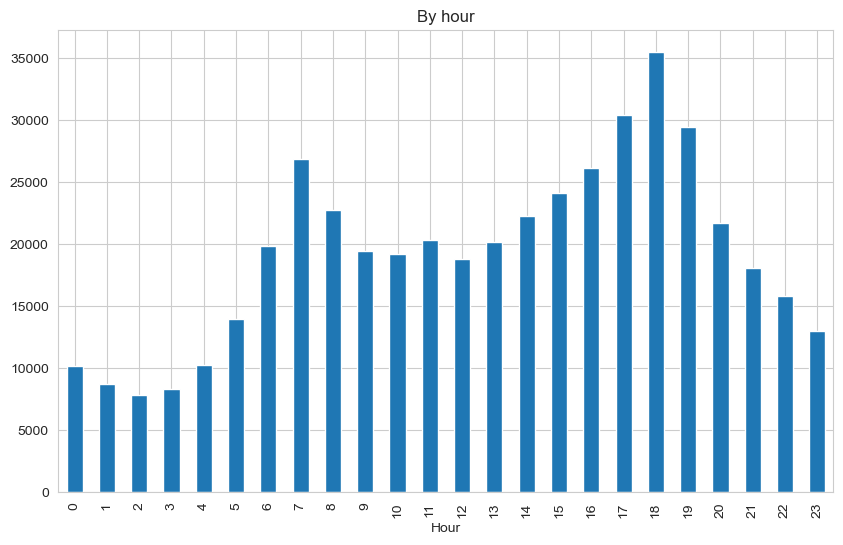

In [38]:
df['Hour'].value_counts().sort_index().plot(kind='bar', title='By hour')

<Axes: title={'center': 'By month'}, xlabel='Month'>

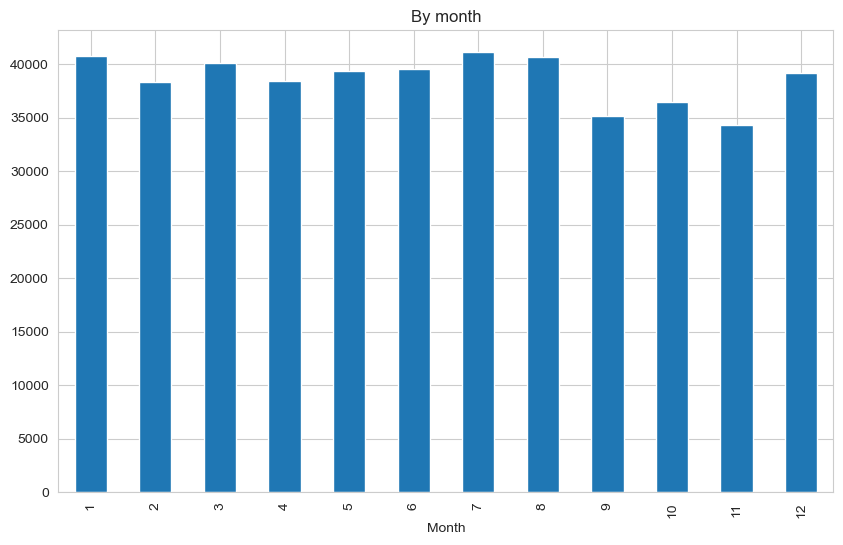

In [39]:
df['Month'].value_counts().sort_index().plot(kind='bar', title='By month')

In [40]:
# Cross-check with Day column:
df['Derived_Day'] = df['Datetime'].dt.day_name()

<Axes: title={'center': 'By name'}, xlabel='Derived_Day'>

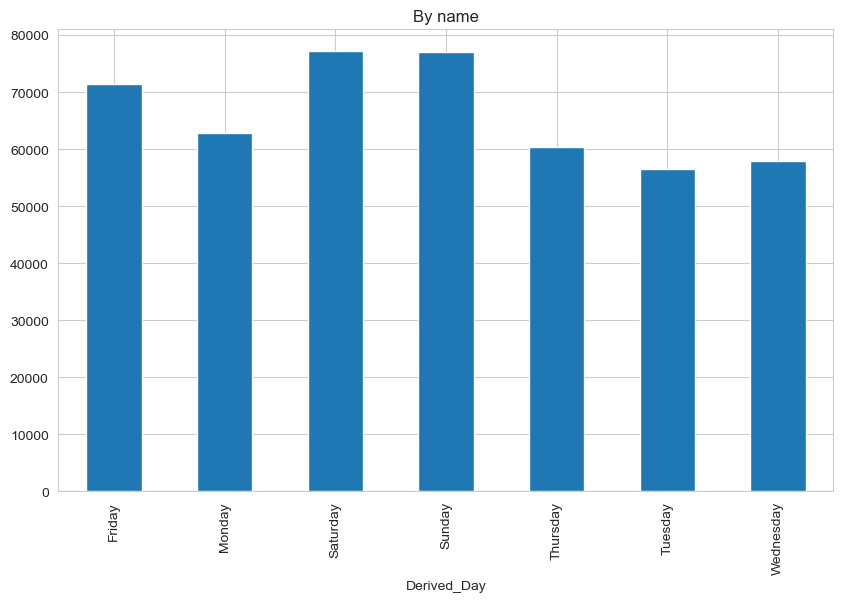

In [41]:
df['Derived_Day'].value_counts().sort_index().plot(kind='bar', title='By name')

In [42]:
(df['Derived_Day'] != df['Day']).sum()

np.int64(463142)

__Condition Check For Victims__

In [43]:
df['Victims_Condition'].value_counts()

Victims_Condition
With injured victims    332211
Without victims          99587
With dead victims        31344
Name: count, dtype: int64

In [44]:
df.groupby('Victims_Condition')['Deaths'].mean().sort_values()

Victims_Condition
With injured victims    0.000000
Without victims         0.000000
With dead victims       1.170814
Name: Deaths, dtype: float64

### Bivariate / Multivariate

In [45]:
df.groupby('Weather_Condition')['Deaths'].sum().sort_values()

Weather_Condition
Snowy            0
Hail             1
Windy           83
Fog            541
Ignored        710
Drizzle       1105
Sunny         1933
Rainy         3865
Cloudy        6055
Clear sky    22405
Name: Deaths, dtype: int64

<Axes: xlabel='Weather_Condition', ylabel='Deaths'>

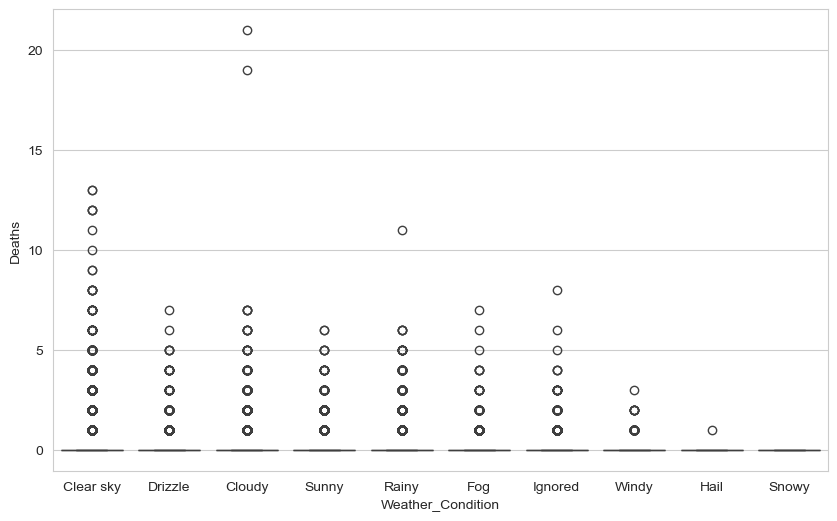

In [46]:
sns.boxplot(x='Weather_Condition',y='Deaths', data=df)

In [47]:
df.groupby('Day_Phase')[['Deaths','Ignored']].mean()

,Deaths,Ignored
Day_Phase,,
Day,0.057010,0.118243
Night,0.109847,0.180359
Sunrise,0.116048,0.159818
Sunset,0.072919,0.156170


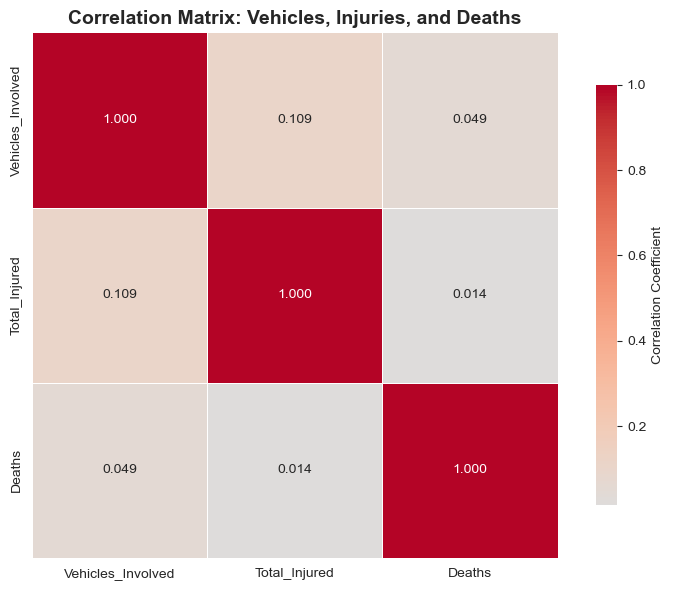

In [48]:
# Calculate correlation
corr_matrix = df[['Vehicles_Involved', 'Total_Injured', 'Deaths']].corr()

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Color scheme 
            center=0,             # Center colormap at 0
            fmt='.3f',            # 3 decimal places
            square=True,          # Square cells
            linewidths=0.5,       # Lines between cells
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix: Vehicles, Injuries, and Deaths', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
df.groupby(['Road_Type','Road_Delineation'])['Deaths'].mean().unstack().style.background_gradient()

Road_Delineation,Authorized U-turn,Bridge,Curve,Intersection,Not Reported,Overpass,Roundabout,Straight,Temporary Detour,Tunnel
Road_Type,,,,,,,,,,
Double,0.029945,0.044910,0.044496,0.021308,0.059407,0.034922,0.017863,0.049874,0.065324,0.019048
Multiple,0.024390,0.024390,0.050230,0.020444,0.058322,0.026786,0.003040,0.038900,0.061278,0.093750
Simple,0.024749,0.148936,0.114854,0.035010,0.130093,0.027563,0.025881,0.114949,0.127698,0.035336


Highest average deaths overall:

    Simple roads + Bridge (0.149), followed by Simple + Straight (0.115), Simple + Curve (0.115), and Simple + Not Reported (0.130).

    Also notable: Multiple + Tunnel (0.094) and Double + Temporary Detour (0.065).

Lowest average deaths:

    Multiple + Roundabout (0.003) – extremely low.
    
    Double + Roundabout (0.018), Double + Tunnel (0.019), and Double + Intersection (0.021) are also low.

By road type:

* Simple roads tend to have higher death averages on most features (Bridge, Curve, Straight, Not Reported).
* Double and Multiple roads show lower averages overall, except for a few features (e.g., Multiple + Tunnel, Double + Temporary Detour).

Not Reported is consistently among the higher values for all three road types – suggesting delineation is unknown, accidents tend to be deadlier.

Roundabouts stand out as the safest delineation across all road types (lowest death averages).

In [50]:
df.groupby('State').apply(lambda x: x['Deaths'].sum() / len(x)).sort_values(ascending=False)

C:\Users\marti\AppData\Local\Temp\ipykernel_42856\2023044963.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('State').apply(lambda x: x['Deaths'].sum() / len(x)).sort_values(ascending=False)


State
MA    0.186234
PA    0.152251
BA    0.140773
TO    0.138903
AM    0.127907
AL    0.126722
PI    0.122037
RR    0.119925
PE    0.110849
CE    0.104885
MT    0.095071
MS    0.089118
GO    0.085502
AP    0.080675
PB    0.080097
SE    0.079566
AC    0.079282
MG    0.078750
RN    0.076873
PR    0.068861
RS    0.065323
RJ    0.062735
RO    0.060627
ES    0.060030
SP    0.048788
SC    0.045256
DF    0.044756
dtype: float64

Interpretation:
* MA has the highest average: ~0.186 deaths per incident.
* PA, BA, TO follow with values around 0.14–0.15.
* SP, SC, DF have the lowest averages (0.0488, 0.0453, 0.0448 respectively).


Since all the values are significantly lower than 1, most accidents do not result in any fatalities.

This means that, with a value of 0.18, there is an average of approximately 1 fatality for every 5–6 accidents in MA.

In [51]:
df[df['Deaths']>0].groupby(
  'State')['Deaths'].mean()

State
AC    1.212389
AL    1.151951
AM    1.137931
AP    1.194444
BA    1.228838
CE    1.110563
DF    1.080000
ES    1.194253
GO    1.217146
MA    1.203050
MG    1.218521
MS    1.214555
MT    1.229730
PA    1.155134
PB    1.101198
PE    1.112903
PI    1.155556
PR    1.158983
RJ    1.125835
RN    1.105346
RO    1.194231
RR    1.109827
RS    1.182682
SC    1.151515
SE    1.103943
SP    1.083032
TO    1.179487
Name: Deaths, dtype: float64

In [52]:
!pip install folium
import folium

In [53]:
m = folium.Map()
fatal = df[df['Deaths'] > 0]
for _, r in fatal.sample(3000).iterrows():
  folium.CircleMarker([r.Latitude,r.Longitude],radius=3, color='red').add_to(m)

display(m)
m.save("map.html")  

In [54]:
df.groupby('Accident_Cause').agg(count=('Deaths','count'),avg_deaths=('Deaths','mean')).sort_values('avg_deaths',ascending=False).head(15)

,count,avg_deaths
Accident_Cause,,
Pedestrian was walking in the road,1780,0.437640
suicide (presumed),5,0.400000
Driver was in the opposite direction,5418,0.374123
Disobedience to laws of transit by the pedestrian,1055,0.334597
Unexpected pedestrian entry,1766,0.305776
Pedestrian's lack of attention,8076,0.301263
Pedestrian was crossing the road outside of the crosswalk,1583,0.254580
The driver passed the next car improperly,9943,0.235140
Urban area without appropriate pedestrian walking,275,0.196364


In [55]:
df[['Ignored','Deaths',
   'Uninjured',
   'Vehicles_Involved']].corr()

,Ignored,Deaths,Uninjured,Vehicles_Involved
Ignored,1.000000,0.081075,-0.068676,0.094325
Deaths,0.081075,1.000000,-0.015386,0.049003
Uninjured,-0.068676,-0.015386,1.000000,0.440609
Vehicles_Involved,0.094325,0.049003,0.440609,1.000000


Uninjured vs Vehicles_Involved	0.441	Moderate positive – more vehicles involved tend to have more uninjured people

Ignored is not meaningfully correlated with deaths, uninjured people, or number of vehicles. It behaves almost independently in the dataset.

In [56]:
df[df['Ignored']>0].groupby(
  'State')['Ignored'].mean()

State
AC    1.238739
AL    1.205742
AM    1.435897
AP    1.259887
BA    1.170306
CE    1.153519
DF    1.141274
ES    1.131433
GO    1.177192
MA    1.210720
MG    1.197889
MS    1.168490
MT    1.166782
PA    1.231100
PB    1.150219
PE    1.167065
PI    1.150039
PR    1.143529
RJ    1.138653
RN    1.122291
RO    1.243884
RR    1.245552
RS    1.185586
SC    1.137982
SE    1.097923
SP    1.144680
TO    1.207039
Name: Ignored, dtype: float64

* Range: around 1.10 to 1.44
* Highest: AM (1.44), followed by AP (1.26), RO (1.24), RR (1.25)
* Lowest: SE (1.10), RN (1.12), SC (1.14), DF (1.14)

In most states, when an incident has any ignored people, the typical number is just above 1 (rarely 2 or more). 

In [57]:
df.groupby('State').apply(lambda x: x['Ignored'].sum() / len(x)).sort_values(ascending=False)

C:\Users\marti\AppData\Local\Temp\ipykernel_42856\3854931866.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('State').apply(lambda x: x['Ignored'].sum() / len(x)).sort_values(ascending=False)


State
AM    0.289406
PB    0.229153
RR    0.218613
PA    0.210797
AP    0.209193
PE    0.209114
MA    0.204870
SE    0.191165
CE    0.177233
PI    0.174490
AL    0.170770
AC    0.159144
RO    0.158840
RN    0.158557
ES    0.153686
MS    0.147487
TO    0.146704
SP    0.145910
BA    0.143157
GO    0.139309
RS    0.138577
PR    0.137721
MG    0.133266
DF    0.124171
RJ    0.116441
SC    0.110722
MT    0.103614
dtype: float64

In the highest state (≈0.29), there is about 1 ignored person for every 3–4 incidents on average.

### Outliers

<Axes: >

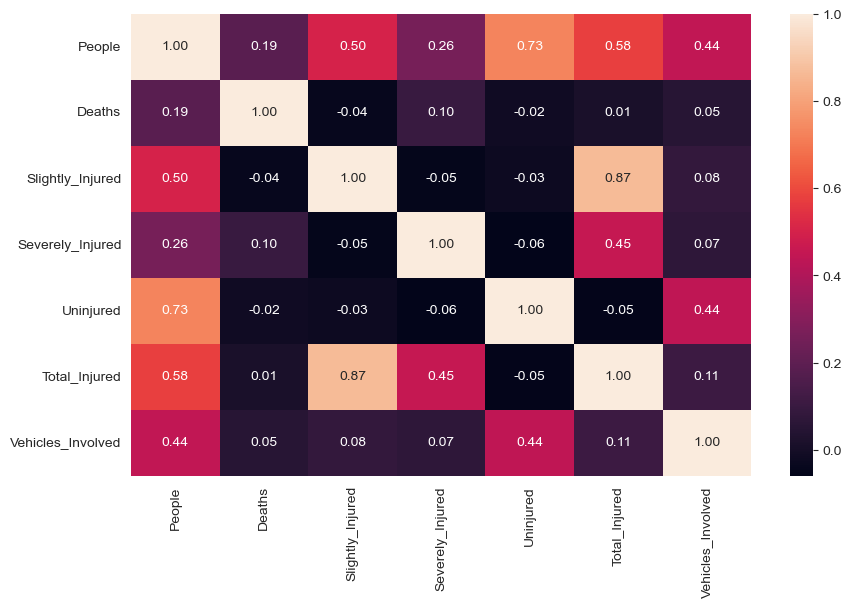

In [58]:
numeric_cols = ['People','Deaths','Slightly_Injured','Severely_Injured','Uninjured','Total_Injured','Vehicles_Involved']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f')

In [59]:

def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]


count_cols = ['People', 'Deaths', 'Slightly_Injured', 'Severely_Injured', 
              'Uninjured', 'Ignored', 'Total_Injured', 'Vehicles_Involved', 'Road_Km']

for col in count_cols:
    outliers = iqr_outliers(df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df):.1%})")

count_cols = ['People', 'Deaths', 'Slightly_Injured', 'Severely_Injured', 
              'Uninjured', 'Ignored', 'Total_Injured', 'Vehicles_Involved', 'Road_Km']

for col in count_cols:
    outliers = iqr_outliers(df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df):.1%})")


lat_min, lat_max = -90, 90   
lon_min, lon_max = -180, 180

invalid_coords = df[
    (df['Latitude'] < lat_min)  | (df['Latitude'] > lat_max) |
    (df['Longitude'] < lon_min) | (df['Longitude'] > lon_max) |
    (df['Latitude'].abs() < 0.01) | (df['Longitude'].abs() < 0.01) 
]
print(f"Invalid coordinates: {len(invalid_coords)}")

People: 8586 outliers (1.9%)
Deaths: 31344 outliers (6.8%)
Slightly_Injured: 20283 outliers (4.4%)
Severely_Injured: 96751 outliers (20.9%)
Uninjured: 37198 outliers (8.0%)
Ignored: 57240 outliers (12.4%)
Total_Injured: 30484 outliers (6.6%)
Vehicles_Involved: 8573 outliers (1.9%)
Road_Km: 4357 outliers (0.9%)
People: 8586 outliers (1.9%)
Deaths: 31344 outliers (6.8%)
Slightly_Injured: 20283 outliers (4.4%)
Severely_Injured: 96751 outliers (20.9%)
Uninjured: 37198 outliers (8.0%)
Ignored: 57240 outliers (12.4%)
Total_Injured: 30484 outliers (6.6%)
Vehicles_Involved: 8573 outliers (1.9%)
Road_Km: 4357 outliers (0.9%)
Invalid coordinates: 50


### Feature-level thinking

Columns:

    Datetime-derived: Hour, Month, Day
    Location: State, City, Regional, Road_ID, Latitude, Longitude
    Road context: Road_Type, Road_Delineation, Road_Km, Km_Direction, Missing_Road_Data
    Weather/time context: Weather_Condition, Day_Phase
    Accident info: Accident_Cause, Accident_Type, Vehicles_Involved, People, Total_Injured
    Victim counts: Deaths, Slightly_Injured, Severely_Injured, Uninjured, Ignored
    Admin: Police_Station
    Target: Victims_Condition

In [60]:
df['Victims_Condition'].value_counts(normalize=True)

Victims_Condition
With injured victims    0.717298
Without victims         0.215025
With dead victims       0.067677
Name: proportion, dtype: float64

In [61]:
for c in ['Road_ID',
  'Police_Station','Regional','State']:
    print(c, df[c].nunique())

Road_ID 130
Police_Station 152
Regional 28
State 27


In [62]:
df.groupby('Victims_Condition')[['Deaths', 'Slightly_Injured', 'Severely_Injured']].mean()

,Deaths,Slightly_Injured,Severely_Injured
Victims_Condition,,,
With dead victims,1.170814,0.477699,0.388081
With injured victims,0.000000,1.119689,0.325209
Without victims,0.000000,0.000000,0.000000


In [63]:
# Does Regional sit inside State?
df.groupby('Regional')['State'].nunique().sort_values(ascending=False).head(10)

Regional
SPRF-BA    4
SPRF-AC    3
SPRF-RO    3
SPRF-PR    3
SPRF-DF    2
SPRF-CE    2
SPRF-MS    2
SPRF-SE    2
SPRF-PE    2
SPRF-PI    2
Name: State, dtype: int64

In [64]:
# Road_ID: 130 unique, use target encoding
road_fatality = df.groupby('Road_ID')['Deaths'].mean()
df['Road_ID_encoded'] = df['Road_ID'].map(road_fatality)

In [65]:
print(road_fatality.sort_values(ascending=False).head(10))

Road_ID
403.0    0.619048
416.0    0.538462
434.0    0.538462
349.0    0.456522
412.0    0.333333
402.0    0.303030
420.0    0.298137
433.0    0.285714
426.0    0.250000
361.0    0.247059
Name: Deaths, dtype: float64


In [66]:
# Police_Station: 152 unique, same approach
station_fatality = df.groupby('Police_Station')['Deaths'].mean()
df['Station_encoded'] = df['Police_Station'].map(station_fatality)

In [67]:
road_freq = df['Road_ID'].value_counts() / len(df)
df['Road_ID_encoded'] = df['Road_ID'].map(road_freq)

Dropping unnecessary columns for the model

In [68]:
df.dtypes

Datetime             datetime64[ns]
Day                          object
State                        object
Road_ID                      object
Road_Km                     float64
City                         object
Accident_Cause               object
Accident_Type                object
Victims_Condition            object
Day_Phase                    object
Km_Direction                 object
Weather_Condition            object
Road_Type                    object
Road_Delineation             object
People                        int64
Deaths                        int64
Slightly_Injured              int64
Severely_Injured              int64
Uninjured                     int64
Ignored                       int64
Total_Injured                 int64
Vehicles_Involved             int64
Latitude                    float64
Longitude                   float64
Regional                     object
Police_Station               object
Missing_Road_Data              bool
Hour                        

In [ ]:
df = df.drop('Day_Phase', axis=1)#leave there

In [ ]:
df = df.drop('City', axis=1)#leave there

In [71]:
df = df.drop('Datetime', axis=1)

In [72]:
df = df.drop('Day', axis=1)

In [ ]:
df = df.drop('Deaths', axis=1)#leave there

In [ ]:
df = df.drop('Slightly_Injured', axis=1)#leave there

In [ ]:
df = df.drop('Severely_Injured', axis=1)#leave there

In [76]:
df = df.drop('Latitude', axis=1)

In [77]:
df = df.drop('Longitude', axis=1)

In [ ]:
df = df.drop('People', axis=1)#leave there

In [79]:
df = df.drop('Total_Injured', axis=1)

In [ ]:
df = df.drop('Uninjured', axis=1)#leave there

In [ ]:
df = df.drop('Ignored', axis=1)#my choice

In [ ]:
df = df.drop('State', axis=1)#leave there

In [83]:
df.dtypes

Road_ID               object
Road_Km              float64
Accident_Cause        object
Accident_Type         object
Victims_Condition     object
Km_Direction          object
Weather_Condition     object
Road_Type             object
Road_Delineation      object
Vehicles_Involved      int64
Regional              object
Police_Station        object
Missing_Road_Data       bool
Hour                   int32
Month                  int32
Derived_Day           object
Road_ID_encoded      float64
Station_encoded      float64
dtype: object